In [23]:
import tensorflow as tf 
import matplotlib.pyplot as plt
import numpy as np

In [2]:

IMAGE_SIZE = 224
BATCH_SIZE = 32

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory="PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
    )

Found 2152 files belonging to 3 classes.


2026-04-09 10:20:40.334081: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-09 10:20:40.643943: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [4]:
class_names = dataset.class_names
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [5]:
def dataset_split(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size = 10000):

    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed = 12)
    train_ds = ds.take(int(train_split * ds_size))
    val_ds = ds.skip(int(train_split * ds_size)).take(int(val_split * ds_size))
    test_ds = ds.skip(int(train_split * ds_size)).skip(int(val_split * ds_size))
    return train_ds, val_ds, test_ds

In [6]:
train_ds, val_ds, test_ds = dataset_split(dataset)

In [7]:
print(len(train_ds), len(val_ds), len(test_ds))

54 6 8


In [8]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [9]:
resize_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    tf.keras.layers.Rescaling(1./255)
    ])

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2)
])

In [11]:
model = tf.keras.Sequential([
    resize_rescale,
    data_augmentation,
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
    
])

model.build(input_shape = (32, IMAGE_SIZE, IMAGE_SIZE, 3))
model.summary()

/home/rohan/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 224, 224, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 112, 112, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 112, 112, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 56, 56, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 56, 56, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 28, 28, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 14, 14, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 7, 7, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 7, 7, 32)         │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 3, 3, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 288)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 512)              │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,643 (768.14 KB)

 Trainable params: 196,643 (768.14 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [13]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    patience = 5
)

In [14]:
history = model.fit(
    train_ds,
    epochs=20,
    batch_size = BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    callbacks = [early_stopping]
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.4425 - loss: 0.9634 - val_accuracy: 0.4375 - val_loss: 0.8632
Epoch 2/20
34/54 ━━━━━━━━━━━━━━━━━━━━ 14s 712ms/step - accuracy: 0.5126 - loss: 0.8805

2026-04-09 10:21:27.092772: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 46 of 10000
2026-04-09 10:21:27.213333: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 251ms/step - accuracy: 0.5458 - loss: 0.8535 - val_accuracy: 0.7135 - val_loss: 0.6896
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 252ms/step - accuracy: 0.7647 - loss: 0.5795 - val_accuracy: 0.8594 - val_loss: 0.3710
Epoch 4/20


2026-04-09 10:21:42.139180: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 30 of 10000
2026-04-09 10:21:26.634997: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 248ms/step - accuracy: 0.8585 - loss: 0.3574 - val_accuracy: 0.9115 - val_loss: 0.2415
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 243ms/step - accuracy: 0.8846 - loss: 0.3135 - val_accuracy: 0.8333 - val_loss: 0.3418
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 256ms/step - accuracy: 0.8993 - loss: 0.2430 - val_accuracy: 0.8750 - val_loss: 0.3189
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 261ms/step - accuracy: 0.9175 - loss: 0.2094 - val_accuracy: 0.7917 - val_loss: 0.5616
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 256ms/step - accuracy: 0.8739 - loss: 0.3047 - val_accuracy: 0.8490 - val_loss: 0.3666
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 254ms/step - accuracy: 0.9277 - loss: 0.1980 - val_accuracy: 0.9427 - val_loss: 0.1886
Epoch 10/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s -72194us/step - accuracy: 0.9525 - loss: 0.1313 - val_accuracy: 0.9323 - val_loss: 0.1514
Epoch 11/20
34/54 ━━━━━━━━━━━━━━━━━━━━ 14s 705ms/step - accuracy: 0.9386 - loss: 0.1657

...

54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 243ms/step - accuracy: 0.9418 - loss: 0.1546 - val_accuracy: 0.9479 - val_loss: 0.1349
Epoch 12/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 240ms/step - accuracy: 0.9271 - loss: 0.2120 - val_accuracy: 0.8698 - val_loss: 0.3488
Epoch 13/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 240ms/step - accuracy: 0.9206 - loss: 0.2070 - val_accuracy: 0.9740 - val_loss: 0.0703
Epoch 14/20
34/54 ━━━━━━━━━━━━━━━━━━━━ 13s 699ms/step - accuracy: 0.9595 - loss: 0.1139

2026-04-09 10:24:12.393367: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 44 of 10000
2026-04-09 10:24:12.517016: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 239ms/step - accuracy: 0.9588 - loss: 0.1147 - val_accuracy: 0.7812 - val_loss: 0.6106
Epoch 15/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 239ms/step - accuracy: 0.9380 - loss: 0.1699 - val_accuracy: 0.9896 - val_loss: 0.0343
Epoch 16/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 242ms/step - accuracy: 0.9805 - loss: 0.0593 - val_accuracy: 0.9740 - val_loss: 0.0807
Epoch 17/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 29s 535ms/step - accuracy: 0.9714 - loss: 0.0560 - val_accuracy: 0.9792 - val_loss: 0.0435
Epoch 18/20
54/54 ━━━━━━━━━━━━━━━━━━━━ -2s -45356us/step - accuracy: 0.9584 - loss: 0.1145 - val_accuracy: 0.9896 - val_loss: 0.0329
Epoch 19/20


2026-04-09 10:25:07.477340: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 29 of 10000
2026-04-09 10:25:07.692752: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


54/54 ━━━━━━━━━━━━━━━━━━━━ 29s 541ms/step - accuracy: 0.9831 - loss: 0.0444 - val_accuracy: 0.9531 - val_loss: 0.1006
Epoch 20/20
54/54 ━━━━━━━━━━━━━━━━━━━━ -2s -51353us/step - accuracy: 0.9704 - loss: 0.0616 - val_accuracy: 0.9792 - val_loss: 0.0691


In [15]:
test_eval = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.9271 - loss: 0.1020


Text(0.5, 1.0, 'Training and Validation Accuracy')

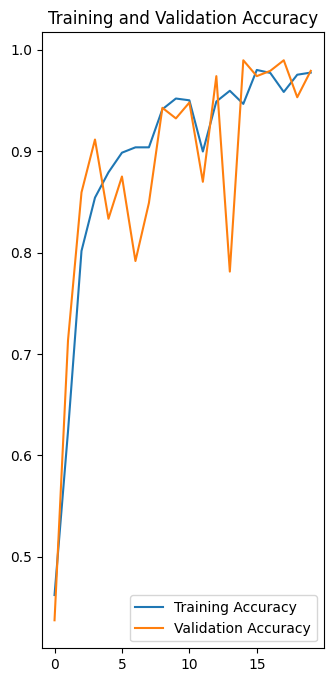

In [17]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))   # FIX HERE

plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

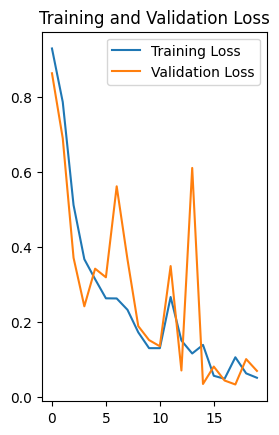

In [18]:
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Potato___Late_blight 0.8813334


2026-04-09 10:34:26.523805: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


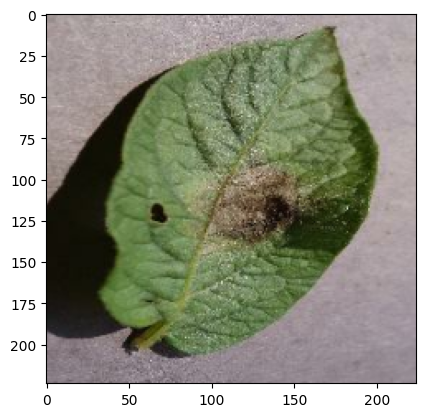

In [19]:
#! prediction 
for image_batch, labels_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    first_label = labels_batch[0].numpy()
    plt.imshow(first_image)

    batch_prediction = model.predict(image_batch)
    confidence = np.max(batch_prediction[0])
    print(class_names[np.argmax(batch_prediction[0])], confidence)
    

In [22]:
model.save("models/potato_model.keras")

In [25]:
load_model = tf.keras.models.load_model("backend/potato_model.keras")

Potato___Early_blight 0.9999999


2026-04-09 11:22:36.607600: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


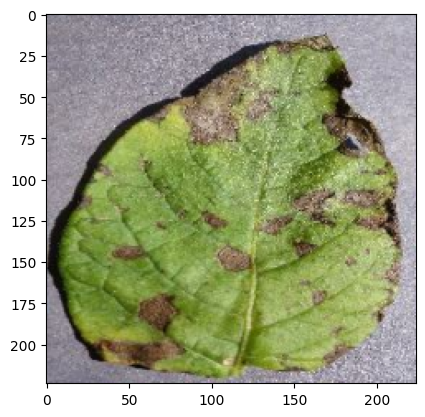

In [33]:
#! prediction 
for image_batch, labels_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    first_label = labels_batch[0].numpy()
    plt.imshow(first_image)

    batch_prediction = load_model.predict(image_batch, verbose=0)
    confidence = np.max(batch_prediction[0])
    print(class_names[np.argmax(batch_prediction[0])], confidence)
    